# Ejercicio 4: Localizaci&oacute;n del Fantasma en Pac-Man

F&oacute;rmula de inferencia bayesiana est&aacute;tica:

$$P(G = g \mid E) \propto P(G = g) \prod_{(i, j) \in E} P(S_{ij} = \text{color} \mid G = g)$$

In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 10

def load_sensor_distribution(path):
    dist = {}
    with open(path, newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        if reader.fieldnames:
            reader.fieldnames = [name.strip() for name in reader.fieldnames]
        for row in reader:
            clean_row = {k.strip(): v for k, v in row.items() if k is not None}
            d = int(clean_row["dist"])
            dist[d] = {k: float(clean_row[k]) for k in ["R", "O", "Y", "G", "B"]}
    return dist

sensor_dist = load_sensor_distribution("Sensor_Color_Distribution.csv")

def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

prior = np.full((GRID_SIZE, GRID_SIZE), 1.0 / (GRID_SIZE * GRID_SIZE))

In [2]:
def compute_posterior(evidence, distance_fn=manhattan):
    posterior = np.zeros((GRID_SIZE, GRID_SIZE), dtype=float)
    for gx in range(GRID_SIZE):
        for gy in range(GRID_SIZE):
            p = prior[gx, gy]
            for (i, j), color in evidence.items():
                d = distance_fn((gx, gy), (i, j))
                p *= sensor_dist.get(d, {}).get(color, 0.0)
            posterior[gx, gy] = p
    total = posterior.sum()
    if total > 0:
        posterior /= total
    return posterior

def map_cell(posterior):
    idx = np.unravel_index(np.argmax(posterior), posterior.shape)
    return idx, posterior[idx]

In [3]:
def plot_posterior(posterior, evidence, title="Posterior"):
    plt.figure(figsize=(5, 5))
    im = plt.imshow(posterior, cmap="magma", origin="upper", extent=[-0.5, 9.5, 9.5, -0.5])
    plt.colorbar(im, label="Probabilidad")
    
    (gx, gy), pmax = map_cell(posterior)
    plt.scatter([gy], [gx], marker="x", color="cyan", s=120, linewidths=2.5, label=f"MAP = ({gx},{gy})")
    
    color_map = {"R": "red", "O": "orange", "Y": "yellow", "G": "green", "B": "blue"}
    for (i, j), color in evidence.items():
        plt.scatter([j], [i], marker="o", color=color_map.get(color, "white"), edgecolors="white", s=100, label=f"Sensor {color}")
        
    plt.title(f"{title} | MAP: ({gx}, {gy})", fontsize=10, fontweight="bold")
    plt.legend(loc="upper right", bbox_to_anchor=(1.4, 1.0))
    plt.xlabel("Columna (y)")
    plt.ylabel("Fila (x)")
    plt.grid(True, which="both", color="white", linestyle="--", linewidth=0.5, alpha=0.2)
    plt.xticks(range(GRID_SIZE))
    plt.yticks(range(GRID_SIZE))
    plt.tight_layout()
    return (gx, gy), pmax

In [4]:
evidence_sets = [
    {(2, 3): "R"},
    {(2, 3): "R", (7, 8): "B"},
    {(2, 3): "R", (7, 8): "B", (4, 1): "Y"}
]

## Inciso a: Plots Colorizados de la Localizaci&oacute;n

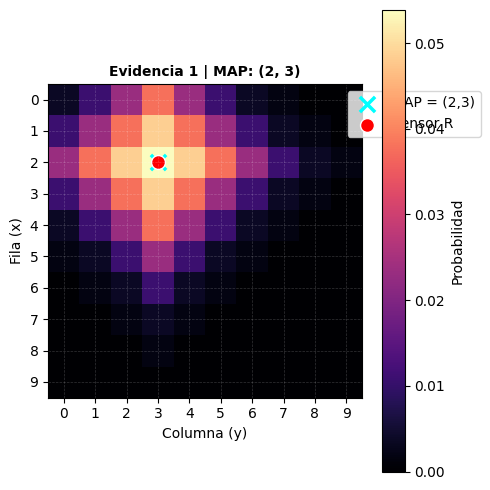

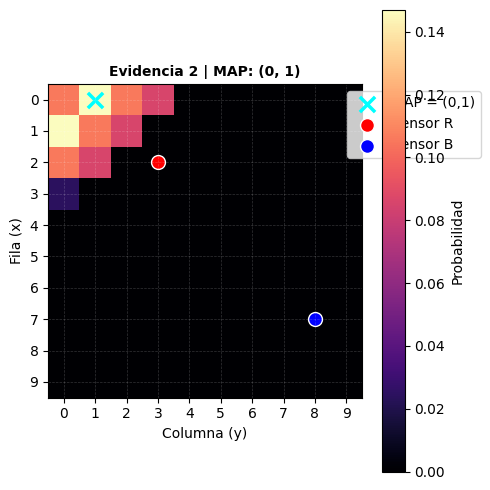

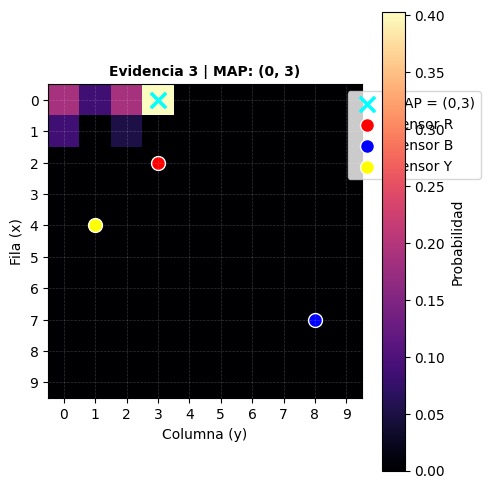

In [5]:
for idx, evidence in enumerate(evidence_sets, start=1):
    posterior = compute_posterior(evidence)
    plot_posterior(posterior, evidence, title=f"Evidencia {idx}")
    plt.show()

### Explicaci&oacute;n Breve de las Gr&aacute;ficas:
*   **Evidencia 1 (Rojo en (2,3)):** Probabilidad concentrada en forma de diamante (Manhattan) alrededor del sensor, con centro en $(2,3)$ (celda MAP).
*   **Evidencia 2 (Rojo en (2,3) + Azul en (7,8)):** La lectura lejana (azul) elimina la probabilidad cerca de $(7,8)$, desplazando la celda MAP a $(0,1)$.
*   **Evidencia 3 (Rojo + Azul + Amarillo en (4,1)):** El sensor amarillo añade restricci&oacute;n de distancia, concentrando la probabilidad casi por completo en $(0,3)$.

## Inciso b: Celdas MAP m&aacute;s Probables

In [6]:
for idx, evidence in enumerate(evidence_sets, start=1):
    posterior = compute_posterior(evidence)
    map_pos, map_prob = map_cell(posterior)
    gx, gy = int(map_pos[0]), int(map_pos[1])
    print(f"Evidencia {idx}: MAP = ({gx}, {gy}) con P = {map_prob:.6f}")

Evidencia 1: MAP = (2, 3) con P = 0.053860
Evidencia 2: MAP = (0, 1) con P = 0.146939
Evidencia 3: MAP = (0, 3) con P = 0.402878
